# attachments 1.0 — turn anything into LLM-ready artifacts

`att("report.pdf")` → text + images you can put straight into a prompt. One function, one output shape, any input.

```bash
pip install attachments            # zero-dep core
pip install attachments[pdf]       # add format support as you need it
```

This notebook is the launch demo — every output below is a real execution against this tree.

In [1]:
# Make a real PDF to play with (pymupdf, already here via attachments[pdf])
import fitz

doc = fitz.open()
for i, line in enumerate(
    [
        "Q1 revenue grew 12% to $4.2M.",
        "Q2 churn dropped to 1.1%.",
        "Outlook: hiring 3 engineers.",
    ],
    1,
):
    page = doc.new_page(width=400, height=200)
    page.insert_text((40, 80), f"Page {i}: {line}", fontsize=12)
doc.save("report.pdf")
doc.close()

### Artifacts — 1 artifact | 110 chars | ~28 tokens | 3 images

```text
## report.pdf
Page 1: Q1 revenue grew 12% to $4.2M.

Page 2: Q2 churn dropped to 1.1%.

Page 3: Outlook: hiring 3 engineers.
```

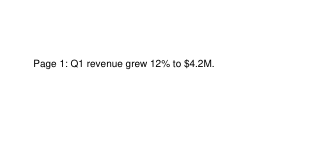
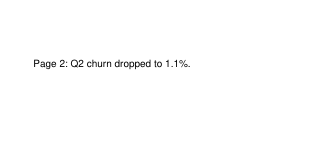
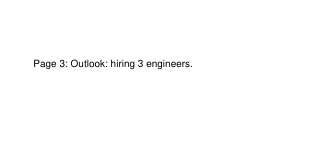

In [2]:
# The whole library is one function
from attachments import att

a = att("report.pdf[images: true, dpi: 60]")
a  # rich repr: summary line + inline page thumbnails (never dumps bytes)

In [3]:
print(a)  # the full assembled prompt — v1's print(ctx) muscle memory
a.tokens  # fast chars/4 approximation

## report.pdf
Page 1: Q1 revenue grew 12% to $4.2M.

Page 2: Q2 churn dropped to 1.1%.

Page 3: Outlook: hiring 3 engineers.


28

In [4]:
# Discovery is built in: every processor declares its option schema
att.options(".pdf")

Option     Type          Aliases  Default  Example           Description
pages      pages         page     —        pages: 1-4        Pages to include: a 1-based
                                                             page number or range.
password   str           pw       —        password: secret  Password for encrypted
                                                             PDFs.
images     bool_or_auto  render   "auto"   images: true      Render pages to PNG:
                                                             true/false, or auto (only
                                                             when no text).
dpi        int           —        200      dpi: 300          Resolution for rendered
                                                             page images.
ocr        bool_or_auto  —        "auto"   ocr: true         OCR scanned pages with
                                                             RapidOCR when there is no
                             

In [5]:
# Errors never raise — they come back as beautiful artifacts
att("missing.pdf")

### Artifacts — 1 artifact | 0 chars | ~0 tokens | 1 error

> ⚠️ `missing.pdf`: unpack-error — unpack failed: Unsupported or non-existent input: missing.pdf

In [6]:
# ...with typed error codes, and "did you mean" warnings for option typos
import pathlib

pathlib.Path("broken.pdf").write_bytes(b"%PDF-1.4 not really a pdf")
print(att("broken.pdf")[0]["meta"]["error"])

pathlib.Path("tiny.csv").write_text("region,sales\nEast,100\nWest,120\n")
att("tiny.csv[row: 5]")[0]["meta"]["warnings"]

Unknown option 'row' for .csv — did you mean 'rows'?


{'code': 'parse-error', 'message': 'Failed to parse PDF: Stream has ended unexpectedly'}


["Unknown option 'row' for .csv — did you mean 'rows'?"]

In [7]:
# The last mile hangs right off the result
msgs = a.claude(
    "Summarize in one sentence."
)  # Claude Messages API dicts, no SDK import
print([block["type"] for block in msgs[0]["content"]])

msgs = a.openai("Summarize in one sentence.")  # OpenAI parts (data-URL images)
print(msgs[0]["content"][0]["type"], "...", msgs[0]["content"][-1]["type"])

a.chunk(max_chars=80)  # segment-aware RAG chunks (pages never split)

['text', 'image', 'image', 'image', 'text']
text ... text


['## report.pdf\nPage 1: Q1 revenue grew 12% to $4.2M.\n\nPage 2: Q2 churn dropped to 1.1%.',
 '## report.pdf\nPage 3: Outlook: hiring 3 engineers.']

In [8]:
# CSV becomes a real markdown table
print(att("tiny.csv"))

## tiny.csv
| region | sales |
| --- | --- |
| East | 100 |
| West | 120 |


In [9]:
# Notebooks are a format too — att() on THIS notebook
nb = att("demo.ipynb")
print(nb[0]["text"][:400])
nb

# attachments 1.0 — turn anything into LLM-ready artifacts

`att("report.pdf")` → text + images you can put straight into a prompt. One function, one output shape, any input.

```bash
pip install attachments            # zero-dep core
pip install attachments[pdf]       # add format support as you need it
```

This notebook is the launch demo — every output below is a real execution against this tr


### Artifacts — 1 artifact | 3,272 chars | ~818 tokens

````text
## demo.ipynb
# attachments 1.0 — turn anything into LLM-ready artifacts

`att("report.pdf")` → text + images you can put straight into a prompt. One function, one output shape, any input.

```bash
pip install attachments            # zero-dep core
pip install attachments[pdf]       # add format support as you need it
```

This notebook is the launch demo — every output below is a real execution against this tree.

```python
# Make a real PDF to play with (pymupdf, already here via attachments[pdf])
import fitz

doc = fitz.open()
for i, line in enumerate([
    "Q1 revenue grew 12% to $4.2M.",

````
… (2,686 more chars)

In [10]:
# The OCR moment: a scanned PDF (image-only, no text layer)
img_doc = fitz.open()
p = img_doc.new_page(width=300, height=100)
p.insert_text((20, 50), "INVOICE TOTAL: $1,234.56", fontsize=14)
pix = p.get_pixmap(dpi=150)
scan = fitz.open()
sp = scan.new_page(width=300, height=100)
sp.insert_image(fitz.Rect(0, 0, 300, 100), stream=pix.tobytes("png"))
scan.save("scan.pdf")
scan.close()
img_doc.close()

s = att("scan.pdf")  # ocr: auto kicks in — no text layer found
print(s[0]["text"])
print(s[0]["meta"]["extra"]["ocr_backend"])

INVOICE TOTAL: $1,234.56
rapidocr


In [11]:
att.help()

attachments 1.0.0 — turn anything into LLM-ready artifacts

Formats (live registry):
  text/code  .cfg .css .ini .java .js .json .log .markdown .md .py .rst .tex .toml .ts .txt .xml .yaml .yml
  pdf        .pdf
  office     .docx .pptx .xls .xlsx
  html       .htm .html
  images     .bmp .gif .heic .heif .jpeg .jpg .png .tif .tiff .webp
  audio      .flac .m4a .mp3 .ogg .opus .wav
  csv        .csv .tsv
  ipynb      .ipynb
  svg        .svg .svgz
  (plus: anything that sniffs as text)

Sources: local files, directories, zip/tar archives, http(s)://, github://

Try:
  a = att("report.pdf[pages: 1-4, images: true]")  # DSL options inline
  a.claude("Summarize.")          # Claude messages (a.openai(...) too)
  a.chunk(max_chars=4000)         # segment-aware RAG chunks

More:
  att.options('.pdf')   options for one processor (att.options() = all)
  docs/dsl-options.md   generated cheatsheet
  spec/                 the binding IR contract & DSL grammar


In [12]:
# Tidy up the scratch files this demo created
import os

for f in ("report.pdf", "scan.pdf", "broken.pdf", "tiny.csv"):
    os.remove(f)

---

**Next:** [README](../README.md) · [ANNOUNCEMENT](../ANNOUNCEMENT.md) · [migrating from 0.25.x](../docs/MIGRATION.md) · the binding contract in [spec/](../spec/)

```bash
pip install attachments
```